In [320]:
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "data"
PLOTS_DIR = "plots"
if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)

In [321]:
def read_dataset(file):
    data_file_path = os.path.join(DATA_DIR, file)
    data_matrix = np.loadtxt(data_file_path)
    input_data = data_matrix[:, :-1]
    output_data = data_matrix[:, -1].reshape((-1, 1))

    return input_data, output_data

def save_plot(fig, filename):
    fig_file_path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(fig_file_path, dpi=300)

In [322]:
X, y = read_dataset("PCB.dt")

x_plot = X.flatten()
plot_order = np.argsort(x_plot.flatten())
x_plot = x_plot[plot_order]
y_plot = y.flatten()[plot_order]

# Task 1

In [323]:
def linear_regression(X, y):
    X_bias = np.hstack((X, np.ones((X.shape[0], 1))))
    X_dagger = np.linalg.pinv(X_bias)
    w_bias = X_dagger @ y
    w, b = w_bias[:-1], w_bias[-1]
    f = lambda X: (X @ w) + b # since we operate on the whole matrix, w.T @ x becomes X @ w
    return w, b, f

def mean_squared_error(y, y_hat):
    return np.mean((y - y_hat) ** 2)

In [324]:
w_linear, b_linear, f_linear = linear_regression(X, y)
y_hat_linear = f_linear(X)
mse_linear = mean_squared_error(y, y_hat_linear)

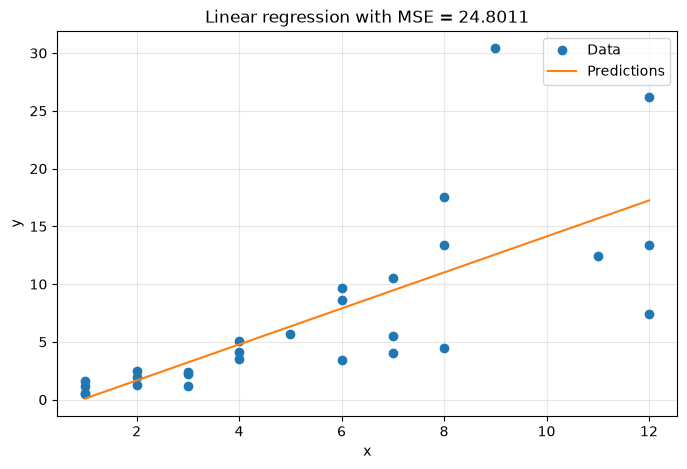

In [325]:
y_hat_linear_plot = y_hat_linear.flatten()[plot_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_plot, y_plot, "o", label="Data")
ax.plot(x_plot, y_hat_linear_plot, "-", label="Predictions")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Linear regression with MSE = {mse_linear:.4f}")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

save_plot(fig, "linear_regression.png")

# Task 2

In [326]:
y_ln = np.log(y)
w_ln, b_ln, f_ln = linear_regression(X, y_ln)
y_hat_exp = np.exp(f_ln(X))
mse_exp = mean_squared_error(y, y_hat_exp)
print("Non-linear h(x)=exp(ax+b) model parameters:")
print(f"  a = {w_ln.flatten()[0]}")
print(f"  b = {b_ln.flatten()[0]}")
print(f"  MSE = {mse_exp:.4f}")

Non-linear h(x)=exp(ax+b) model parameters:
  a = 0.2591282395640714
  b = 0.031472469714475815
  MSE = 34.8356


# Task 4

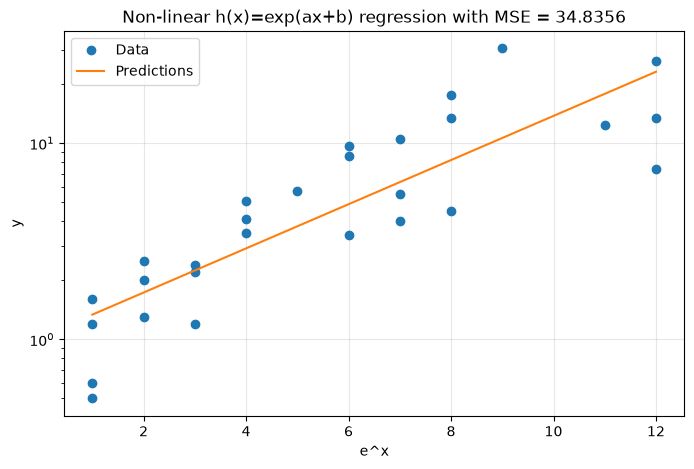

In [327]:
y_hat_exp_plot = y_hat_exp.flatten()[plot_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_plot, y_plot, "o", label="Data")
ax.plot(x_plot, y_hat_exp_plot, "-", label="Predictions")
ax.set_xlabel("e^x")
ax.set_ylabel("y")
ax.set_yscale("log")
ax.set_title(f"Non-linear h(x)=exp(ax+b) regression with MSE = {mse_exp:.4f}")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

save_plot(fig, "non_linear_exp_regression.png")

# Task 5

In [328]:
def r2_score(y, y_hat):
    y_bar = np.mean(y)
    return 1 - (np.sum((y - y_hat) ** 2) / np.sum((y - y_bar) ** 2))

r2_exp = r2_score(y, y_hat_exp)
print(f"R^2 score for non-linear h(x)=exp(ax+b) regression: {r2_exp:.4f}")

R^2 score for non-linear h(x)=exp(ax+b) regression: 0.3570


# Task 6

In [329]:
y_ln = np.log(y)
X_sqrt = np.sqrt(X)
w_sqrt_ln, b_sqrt_ln, f_sqrt_ln = linear_regression(X_sqrt, y_ln)
y_hat_sqrt_exp = np.exp(f_sqrt_ln(X_sqrt))
mse_sqrt_exp = mean_squared_error(y, y_hat_sqrt_exp)
print("Non-linear h(x)=exp(a*sqrt(x)+b) model parameters:")
print(f"  a = {w_sqrt_ln.flatten()[0]}")
print(f"  b = {b_sqrt_ln.flatten()[0]}")
print(f"  MSE = {mse_sqrt_exp:.4f}")

Non-linear h(x)=exp(a*sqrt(x)+b) model parameters:
  a = 1.1986063028078147
  b = -1.1947508236636417
  MSE = 28.0844


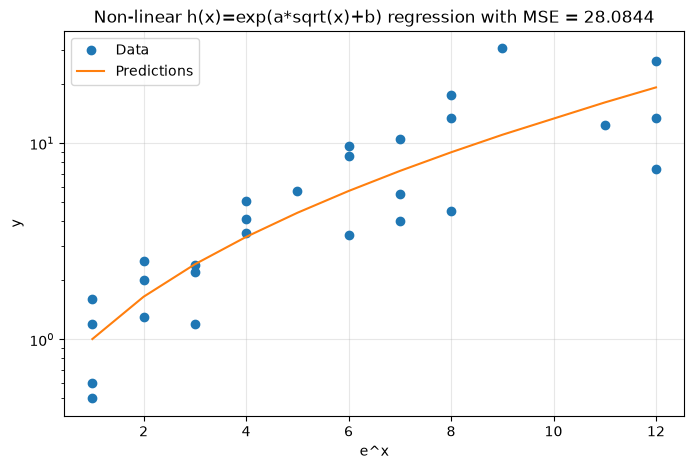

In [330]:
y_hat_sqrt_exp_plot = y_hat_sqrt_exp.flatten()[plot_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_plot, y_plot, "o", label="Data")
ax.plot(x_plot, y_hat_sqrt_exp_plot, "-", label="Predictions")
ax.set_xlabel("e^x")
ax.set_ylabel("y")
ax.set_yscale("log")
ax.set_title(f"Non-linear h(x)=exp(a*sqrt(x)+b) regression with MSE = {mse_sqrt_exp:.4f}")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

save_plot(fig, "non_linear_sqrt_exp_regression.png")

In [331]:
r2_sqrt_exp = r2_score(y, y_hat_sqrt_exp)
print(f"R^2 score for non-linear h(x)=exp(a*sqrt(x)+b) regression: {r2_sqrt_exp:.4f}")

R^2 score for non-linear h(x)=exp(a*sqrt(x)+b) regression: 0.4816
